<a href="https://colab.research.google.com/github/dfreyes/m2t1/blob/main/m2t1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Taller: Contestando Preguntas sobre los Datos

---

###Objetivos del Proyecto
*   **Adquisición de datos:** Realizar la adquisición de una API de datos meteorológicos y visualizar los datos mediante la API de **Open-Meteo**.
*   **Exploración de datos:** Plantear preguntas sobre los datos y y contestarlas de forma visual.

---

###Fundamentos de ciencia de datos
Modulo 2 Tarea 1
|   |   |
| :--- | :--- |
| **Autor:** | Ing. Diego F. Reyes Y. |
| **Fecha:** | Septiembre 2026 |
| **Fuente de Datos:** | [Open-Meteo.com](https://open-meteo.com) *(API de acceso público)* |
---



---




#Logistica de un vuelo seguro para drone DJI Mini 3
---
**Problema a resolver:**  
Se requiere identificar la o las mejores ventanas operativa para ejecutar el vuelo de un vuelo de drone a una altura de 80 m y a maxima velocidad horizontal de 16 m/s de manera segura, minimizando el riesgo que esta asociado a las condiciones de factores meteorológicos.

**Preguntas orientadoras a responder**

1. ¿Cuáles fueron las condiciones del tiempo en la zona de vuelo durante los últimos tres días?
2. Conforme al pronóstico del tiempo respecto a las variables meteorológicas para los próximos tres días, ¿Cuáles  son las condiciones del tiempo en la zona de vuelo?
3. ¿Cuál es la mejor rango horario para ejecutar el vuelo seguro del drone?

---


##Umbrales de seguridad del drone DJI Mini 3
---

| Variable Meteorológica | Umbral Operativo Máximo | Impacto en el Vuelo |
| :--- | :--- | :--- |
| **Velocidad de Viento** | 10.7 m/s | Límite de resistencia física del motor (Nivel 5). |
| **Precipitación** | 0.0 mm (Sin lluvia/nieve) | Riesgo de cortocircuito y pérdida de aerodinámica. |
| **Temperatura** | -10°C a 40°C | Degradación de batería o sobrecalentamiento. |
| **Visibilidad** | Despejado | Seguridad de transmisión y reducción de riesgo de colocion con otros objetos. |

---


#Desarrollo del Análisis

---

El flujo trabjo sigue la siguiente ruta:

1. **Adquisición de Datos:** Conexión automatizada a la API y descarga del histórico y pronóstico  de variables meteorológicas.
2. **Revisión de la data:** Inspección del esquema, tipos de datos y verificación de valores nulos o anomalías.
3. **Análisis Exploratorio de Datos:** Procesamiento estadístico y visualización de variables críticas.
4. **Resolución de Preguntas:** Evaluación de umbrales operativos para la toma de decisiones.
---

**1. Adquisición de Datos:**

In [204]:
#///      Instalación de librerías

!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas


In [205]:
#///      Importar librerías

# Importa la librería oficial de Open-Meteo para realizar peticiones optimizadas
import openmeteo_requests

# Importa Pandas, utilizada para estructurar, limpiar y analizar los datos en tablas (DataFrames)
import pandas as pd

# Importa un módulo para crear una caché de almacenamiento local, evita hacer la misma petición web una y otra vez, guardando las respuestas en la memoria o disco
import requests_cache

# Importa una herramienta que reintenta automáticamente las peticiones web si fallan
from retry_requests import retry

In [206]:
#///      Cofiguración de párametros para la adquisición de datos

# Crea una base de datos local llamada '.cache' que almacena las respuestas por 1 hora (3600 segundos)
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)

# Define que si una petición falla, se reintente hasta 5 veces esperando un tiempo incremental (backoff_factor)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)

# Inicializa el cliente oficial de Open-Meteo inyectándole la sesión tolerante a fallos
openmeteo = openmeteo_requests.Client(session = retry_session)

# URL base para obtener pronósticos y datos recientes de Open-Meteo
url = "https://api.open-meteo.com/v1/forecast"

params = {"latitude": -0.303938,"longitude": -78.533433, # Ubicación
	"hourly": ["apparent_temperature", "precipitation", "cloud_cover", "visibility", "wind_speed_10m", "wind_speed_80m", "wind_speed_120m", "cloud_cover_low", "precipitation_probability", "cloud_cover_mid", "cloud_cover_high",  "wind_direction_80m" ],
	"models": "best_match",          # Selecciona automáticamente el mejor modelo meteorológico para la zona
	"timezone": "auto",              # Ajusta la zona horaria automáticamente según las coordenadas (America/Guayaquil)
	"past_days": 3,                  # Trae datos históricos de los últimos 3 días
	"forecast_days": 4               # Trae el pronóstico para los próximos 3 días
}


In [207]:
#///  Ejecutar petición

# Envía la solicitud y guarda la respuesta cruda (binaria optimizada) en la variable 'responses'
responses = openmeteo.weather_api(url, params = params)

# Seleccionar la primera ubicación devuelta por la API (útil si se pasa una lista de coordenadas)
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m s.n.m.m.")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Procesar datos metereologicos
hourly = response.Hourly()
hourly_apparent_temperature = hourly.Variables(0).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(1).ValuesAsNumpy()
hourly_cloud_cover = hourly.Variables(2).ValuesAsNumpy()
hourly_visibility = hourly.Variables(3).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(4).ValuesAsNumpy()
hourly_wind_speed_80m = hourly.Variables(5).ValuesAsNumpy()
hourly_wind_speed_120m = hourly.Variables(6).ValuesAsNumpy()
hourly_cloud_cover_low = hourly.Variables(7).ValuesAsNumpy()
hourly_precipitation_probability = hourly.Variables(8).ValuesAsNumpy()
hourly_cloud_cover_mid = hourly.Variables(9).ValuesAsNumpy()
hourly_cloud_cover_high = hourly.Variables(10).ValuesAsNumpy()
hourly_wind_direction_80m = hourly.Variables(11).ValuesAsNumpy()

# Generación del rango de fechas y horas adaptado dinámicamente a la zona horaria local del punto de vuelo
hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

# Mapear los arrays de NumPy estructurados directamente en el diccionario de datos
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["precipitation"] = hourly_precipitation
hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["visibility"] = hourly_visibility
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_speed_80m"] = hourly_wind_speed_80m
hourly_data["wind_speed_120m"] = hourly_wind_speed_120m
hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
hourly_data["precipitation_probability"] = hourly_precipitation_probability
hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
hourly_data["cloud_cover_high"] = hourly_cloud_cover_high
hourly_data["wind_direction_80m"] = hourly_wind_direction_80m

# Instanciación final del DataFrame estructurado para la fase de Análisis Exploratorio (EDA)

hourly_dataframe = pd.DataFrame(data = hourly_data)
#print("\nHourly data\n", hourly_dataframe)



Coordinates: -0.3163444399833679°N -78.5390625°E
Elevation: 2957.0 m s.n.m.m.
Timezone: b'America/Guayaquil'b'GMT-5'
Timezone difference to GMT+0: -18000s


**2. Cleaning Data**

Verificando las caracteristicas del set de datos

In [208]:
# Ver la estructura, tipos de datos y si faltan horas por registrar
# Verificar tipo de dato, nulos.
hourly_dataframe.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype                            
---  ------                     --------------  -----                            
 0   date                       168 non-null    datetime64[ns, America/Guayaquil]
 1   apparent_temperature       168 non-null    float32                          
 2   precipitation              168 non-null    float32                          
 3   cloud_cover                168 non-null    float32                          
 4   visibility                 168 non-null    float32                          
 5   wind_speed_10m             168 non-null    float32                          
 6   wind_speed_80m             168 non-null    float32                          
 7   wind_speed_120m            168 non-null    float32                          
 8   cloud_cover_low            168 non-null    float32                    

In [209]:
# Ver cuántas filas duplicadas existen en total
print(f"Filas duplicadas: {hourly_dataframe.duplicated().sum()}")

Filas duplicadas: 0


In [210]:
# Filtra solo las columnas numéricas y cuenta cuántas celdas son menores a 0
negativos_por_variable = (hourly_dataframe.select_dtypes(include='number') < 0).sum()

print("Cantidad de valores menores a 0 por columna:")
print(negativos_por_variable)


Cantidad de valores menores a 0 por columna:
apparent_temperature         0
precipitation                0
cloud_cover                  0
visibility                   0
wind_speed_10m               0
wind_speed_80m               0
wind_speed_120m              0
cloud_cover_low              0
precipitation_probability    0
cloud_cover_mid              0
cloud_cover_high             0
wind_direction_80m           0
dtype: int64


**3. Exploratory Data Analysis**

Analizando y explorando los datos en función a las preguntas orientadoras


In [211]:
#print("░▒▓█" + "█" * 50 + "█▓▒░")
print(" • " * 20)
print(f"\033[1mUbicación de lugar de vuelo\033[0m")
print(f"Coordenadas Latitud, Longitud: {response.Latitude()}°N {response.Longitude()}°E")

from geopy.geocoders import Nominatim
# Inicializar el geolocalizador (debes poner un nombre de usuario cualquiera en user_agent)
geolocalizador = Nominatim(user_agent="mi_aplicacion_de_mapas")
# Definir las coordenadas (Latitud, Longitud)
coordenadas = str(response.Latitude())+","+str(response.Longitude())  # Ejemplo: Quito, Ecuador
try:
    # Realizar la geocodificación inversa
    ubicacion = geolocalizador.reverse(coordenadas)
    # Imprimir la dirección completa o solo el nombre del lugar
    print("Dirección completa:", ubicacion.address)
except Exception as e:
    print("Error al obtener la ubicación:", e)

print(f"Elevación: {response.Elevation()} m s.n.m.m.")

#  Guardamos la elevación en una variable para no llamar al método varias veces
elevacion = response.Elevation()
# Imprimimos el encabezado en negrita
print(" • " * 20)
print("\033[1mSe puede despegar y volar dada la altitud de la ubicación?:\033[0m")
# Evaluamos la condición de manera limpia
if elevacion <= 3000:
    print("¡Sí se puede despegar y volar desde la ubicación!")
else:
    print("No se puede despegar y volar (Excede el límite seguro)")

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Ubicación de lugar de vuelo
Coordenadas Latitud, Longitud: -0.3163444399833679°N -78.5390625°E
Dirección completa: E3, 28 de Noviembre, Turubamba, Quito, Pichincha, 170123, Ecuador
Elevación: 2957.0 m s.n.m.m.
 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Se puede despegar y volar dada la altitud de la ubicación?:
¡Sí se puede despegar y volar desde la ubicación!


In [212]:
# Obtenemos el primer y último registro de la columna date
fecha_inicio = hourly_dataframe['date'].min()
fecha_fin = hourly_dataframe['date'].max()

# Formateamos las fechas para que sean fáciles de leer (Día/Mes/Año Hora:Minutos)
formato = "%d/%m/%Y a las %H:%M"
inicio_legible = fecha_inicio.strftime(formato)
fin_legible = fecha_fin.strftime(formato)

# Imprimimos el reporte con las variables
print(" • " * 20)
print("\033[1m ¿Cúal es el rango temporal del conjunto de datos metereologicos?\033[0m")
print(f"Desde el: \033[1m{inicio_legible}\033[0m")
print(f"Hasta el: \033[1m{fin_legible}\033[0m")

# Desempaquetamos la tupla (filas, columnas)
#filas, columnas = hourly_dataframe.shape
#print(f"El conjunto de datos contiene \033[1m{filas}\033[0m registros y \033[1m{columnas}\033[0m columnas.")

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 ¿Cúal es el rango temporal del conjunto de datos metereologicos?
Desde el: 22/09/2026 a las 00:00
Hasta el: 28/09/2026 a las 23:00


In [213]:
# Importar librerias
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import seaborn as sns
import warnings as wr
import datetime


import numpy as np

# wr.filterwarnings('ignore')


In [214]:
print(" • " * 20)
#  ¿Cuáles es el rango del tiempo en la zona de vuelo con el drone hace tres días.?
print(f"\033[1mFiltro de horario 08:00 a 16:30 \033[0m")
print(" • " * 20)
print(f"\033[1m¿Cuáles son las caracteristicas del tiempo en la zona de vuelo con el drone hace tres días.? \033[0m")

# Filtro Dinámico de Fechas (Últimos 3 días a partir de hoy)
hoy = datetime.date.today()- datetime.timedelta(days=1)
hace_tres_dias = hoy - datetime.timedelta(days=4)

#print(f"Analizando rango dinámico: Desde {hace_tres_dias} hasta {hoy}")
# Forzar conversión a datetime si no se ha hecho
#hourly_dataframe["date"] = pd.to_datetime(hourly_dataframe["date"])

# Aplicamos los filtros combinados
filtro_fechas = hourly_dataframe["date"].dt.date.between(hace_tres_dias, hoy)
filtro_horario = hourly_dataframe["date"].dt.time.between(datetime.time(8, 0), datetime.time(16, 30))
df_laboral = hourly_dataframe[filtro_horario & filtro_fechas].copy()

# Creamos una columna limpia para el eje X que muestre Día y Hora (Ej: "21-Sep 08:00")
df_laboral["dia_hora"] = df_laboral["date"].dt.strftime("%d-%b %H:%M")
#print(df_laboral)
#df_laboral.to_csv('reporte_vuelo_laboral.csv', index=False, encoding='utf-8-sig')
df_laboral.describe().T

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Filtro de horario 08:00 a 16:30 
 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
¿Cuáles son las caracteristicas del tiempo en la zona de vuelo con el drone hace tres días.? 


,count,mean,std,min,25%,50%,75%,max
apparent_temperature,36.0,15.964591,2.956182,11.125296,14.215686,15.840259,17.473636,22.345272
precipitation,36.0,0.408333,1.077398,0.000000,0.000000,0.000000,0.225000,4.900000
cloud_cover,36.0,88.527779,16.348850,19.000000,84.000000,95.000000,98.250000,100.000000
visibility,36.0,32943.890625,25811.302734,2180.000000,8600.000000,23090.000000,62140.000000,67180.000000
wind_speed_10m,36.0,5.962760,3.311354,0.540000,3.573190,5.022979,8.330771,13.262714
wind_speed_80m,36.0,7.652206,4.416559,1.403540,4.340337,6.407674,11.008809,17.343977
wind_speed_120m,36.0,8.013384,4.625016,1.469785,4.545197,6.710110,11.528415,18.162596
cloud_cover_low,36.0,16.638889,14.085763,0.000000,6.000000,12.500000,22.000000,65.000000
precipitation_probability,36.0,28.694445,32.070297,0.000000,2.000000,14.500000,54.000000,100.000000
cloud_cover_mid,36.0,41.361111,29.068544,2.000000,18.250000,37.500000,61.500000,100.000000


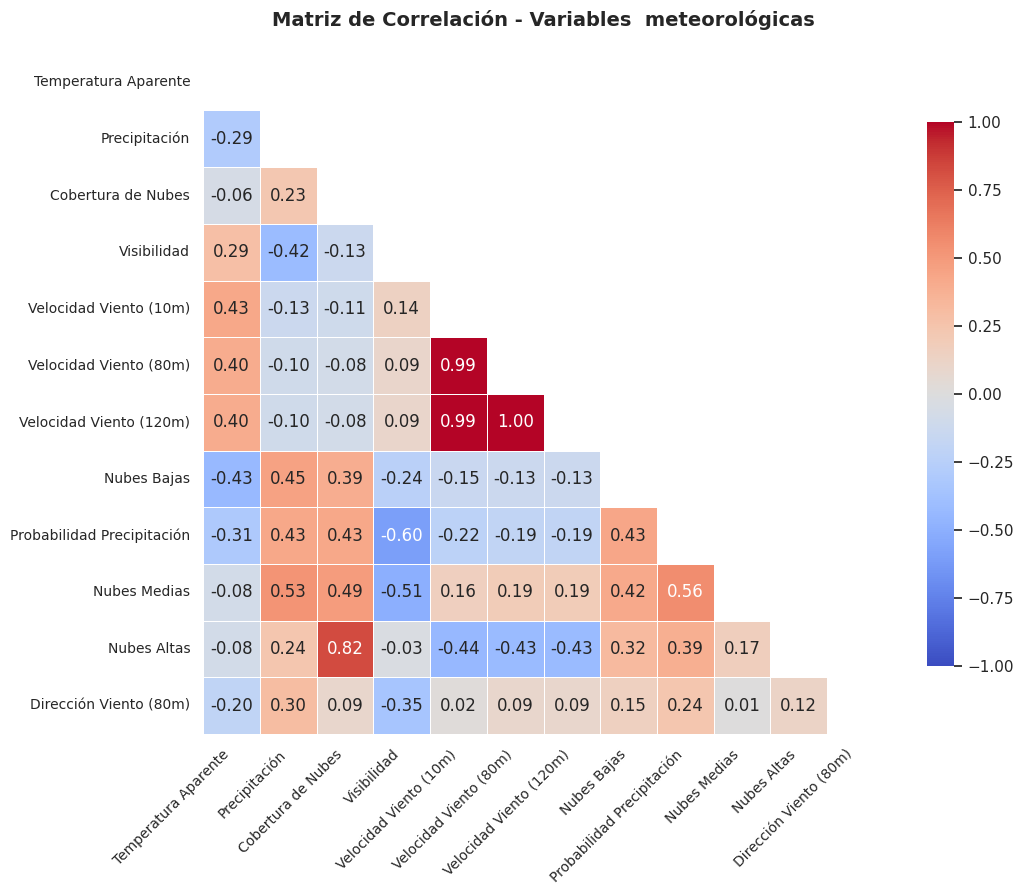

In [215]:

# Diccionario de traducción para las variables meteorológicas/laborales
traduccion = {
    "apparent_temperature": "Temperatura Aparente",
    "precipitation": "Precipitación",
    "cloud_cover": "Cobertura de Nubes",
    "visibility": "Visibilidad",
    "wind_speed_10m": "Velocidad Viento (10m)",
    "wind_speed_80m": "Velocidad Viento (80m)",
    "wind_speed_120m": "Velocidad Viento (120m)",
    "cloud_cover_low": "Nubes Bajas",
    "precipitation_probability": "Probabilidad Precipitación",
    "cloud_cover_mid": "Nubes Medias",
    "cloud_cover_high": "Nubes Altas",
    "wind_direction_80m": "Dirección Viento (80m)"
}

#  Renombrar las columnas en una copia temporal antes de correlacionar
df_espanol = df_laboral.rename(columns=traduccion)

#  Calcular la matriz con los nuevos nombres en español
matriz_corr = df_espanol.corr(numeric_only=True)

#  Configurar el diseño gráfico
plt.figure(figsize=(11, 9))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

# Títulos y rotación ajustada para etiquetas largas en español
plt.title("Matriz de Correlación - Variables  meteorológicas", fontsize=14, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Una grafica que indique las caracteristicas del tiempo en la zona de vuelo con el drone hace tres días. 


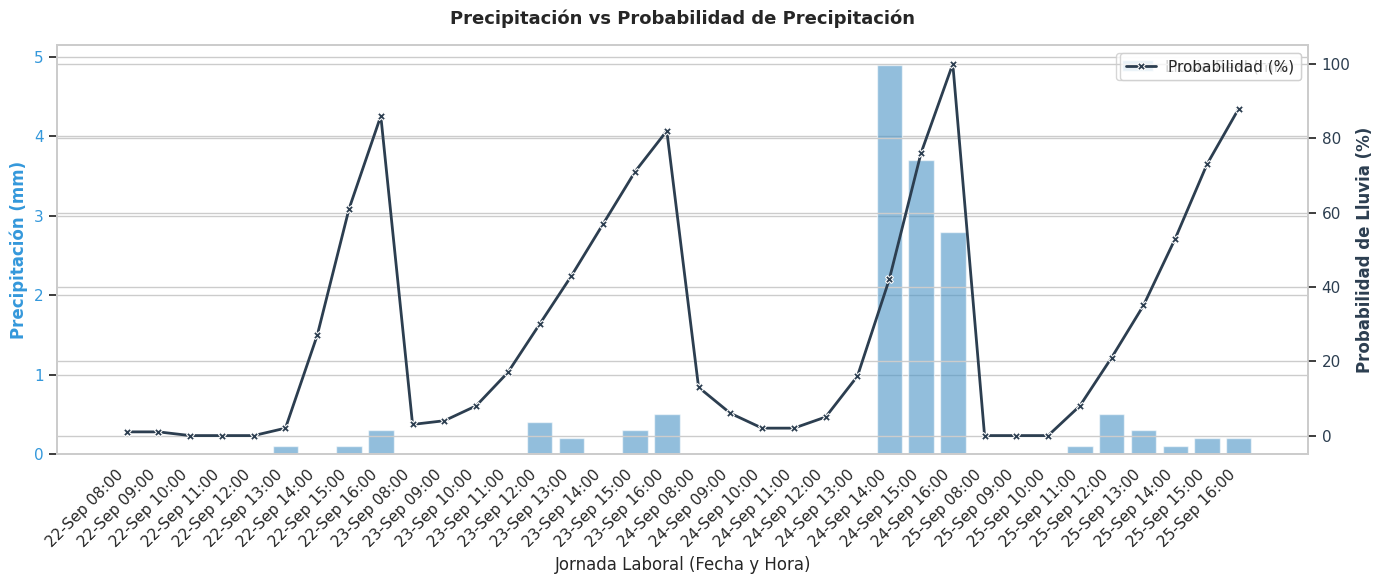

El análisis de las variables muestra un comportamiento cíclico y repetitivo a 
lo largo de las jornadas, caracterizado por una estabilidad con valores mínimos 
durante las horas de la mañana y un incremento sistemático de los picos máximos 
en el bloque vespertino. Existe una alta correlación morfológica entre ambas curvas, 
donde el aumento en el porcentaje de probabilidad anticipa o acompaña de forma directa 
al registro de la precipitación física; no obstante, se evidencia una asimetría en 
la intensidad, ya que valores de probabilidad similares o elevados no se traducen 
de manera lineal en la misma severidad o volumen de precipitación real.


In [216]:
print(" • " * 20)
print(f"\033[1mUna grafica que indique las caracteristicas del tiempo en la zona de vuelo con el drone hace tres días. \033[0m")
# Ajustamos el estilo global de los gráficos independientes
sns.set_theme(style="whitegrid")


# Combinar barras y líneas ayuda a entender mejor los eventos de lluvia
plt.figure(figsize=(14, 6))
ax1 = plt.gca()

# Barra para la lluvia real (Precipitation)
sns.barplot(
    data=df_laboral,
    x="dia_hora",
    y="precipitation",
    color="#3498db",
    alpha=0.6,
    label="Lluvia Real (mm)",
    ax=ax1,
)
ax1.set_ylabel("Precipitación (mm)", color="#3498db", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#3498db")

# Línea para la probabilidad de lluvia
ax2 = ax1.twinx()
sns.lineplot(
    data=df_laboral,
    x="dia_hora",
    y="precipitation_probability",
    color="#2c3e50",
    marker="X",
    linewidth=2,
    label="Probabilidad (%)",
    ax=ax2,
)
ax2.set_ylabel("Probabilidad de Lluvia (%)", color="#2c3e50", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#2c3e50")

ax1.set_xticklabels(df_laboral["dia_hora"], rotation=45, ha="right")
ax1.set_xlabel("Jornada Laboral (Fecha y Hora)")
plt.title(
    "Precipitación vs Probabilidad de Precipitación",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

print("""El análisis de las variables muestra un comportamiento cíclico y repetitivo a
lo largo de las jornadas, caracterizado por una estabilidad con valores mínimos
durante las horas de la mañana y un incremento sistemático de los picos máximos
en el bloque vespertino. Existe una alta correlación morfológica entre ambas curvas,
donde el aumento en el porcentaje de probabilidad anticipa o acompaña de forma directa
al registro de la precipitación física; no obstante, se evidencia una asimetría en
la intensidad, ya que valores de probabilidad similares o elevados no se traducen
de manera lineal en la misma severidad o volumen de precipitación real.""")

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Segunda grafica que indique las caracteristicas del tiempo en la zona de vuelo con el drone hace tres días. 


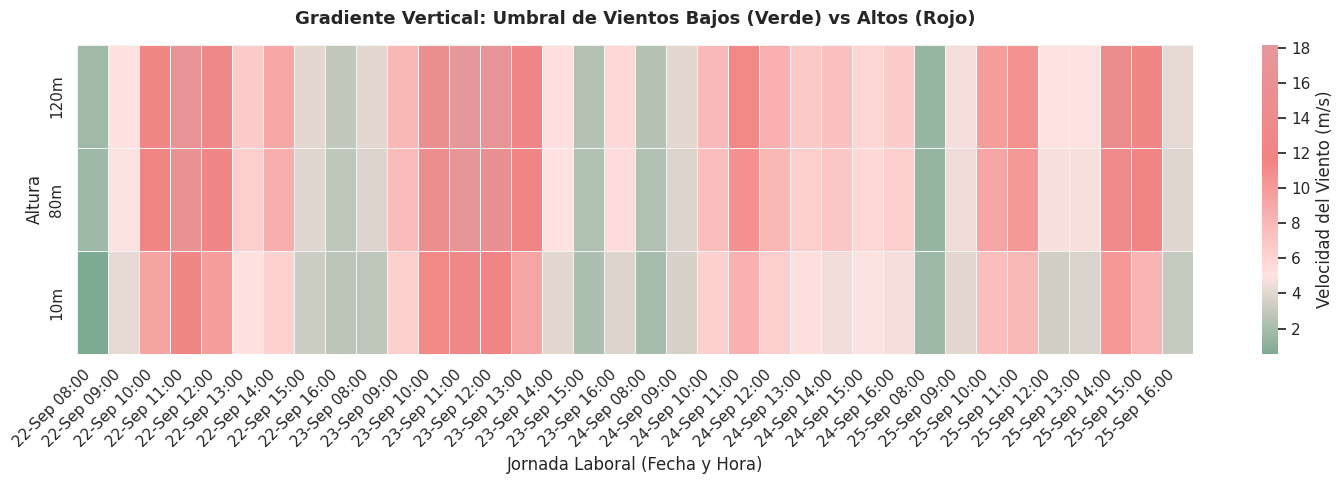

El análisis del gradiente vertical de vientos revela un patrón espacio-temporal,
donde las mayores velocidades (tonos rojos, superiores a 8-10 m/s) se 
concentran sistemáticamente en los niveles superiores de altura de 80m y 120m durante las horas 
centrales y vespertinas de cada jornada. Por el contrario, se identifican ventanas de 
operación segura con vientos bajos (tonos verdes y grisáceos, inferiores a 4-6 m/s) 
principalmente en las primeras horas de la mañana (08:00 a 09:00), observándose el 
fenómeno de cizalladura o gradiente vertical donde la velocidad del viento se incrementa 
de manera proporcional con la altura en casi todos los intervalos medidos.


In [217]:
print(" • " * 20)
print(f"\033[1mSegunda grafica que indique las caracteristicas del tiempo en la zona de vuelo con el drone hace tres días. \033[0m")

#  Preparar los datos
df_heatmap = df_laboral.set_index("dia_hora")[
    [ "wind_speed_120m", "wind_speed_80m", "wind_speed_10m"]
].T
df_heatmap.index = df_heatmap.index.str.replace("wind_speed_", "")

#  CREAR PALETA PERSONALIZADA (Verde -> Amarillo/Neutro -> Rojo)
# El verde representa vientos < 5 y el rojo vientos > 5
#colores = ["#2b8a3e", "#a9e34b", "#fff3bf", "#e63946", "#9b1c1c"]
#colores = ["#2d6a4f", "#95d5b2", "#ffe3e2", "#f28482", "#9b2226"]
colores = ["#1b4332", "#40916c", "#ffe3e2", "#f28482", "#e5989b"]

mi_mapa_color = mcolors.LinearSegmentedColormap.from_list(
    "viento_custom", colores
)

# Graficar
plt.figure(figsize=(15, 5))

# 'vmax' y 'vmin' ayudan a centrar el mapa. Si tu viento máx es p.ej. 12, el centro (5) quedará bien balanceado.
sns.heatmap(
    df_heatmap,
    cmap=mi_mapa_color,
    center=5,
    cbar_kws={"label": "Velocidad del Viento (m/s)"},
    linewidths=0.5,
    linecolor="#f1f3f5",
)

plt.title(
    "Gradiente Vertical: Umbral de Vientos Bajos (Verde) vs Altos (Rojo)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Jornada Laboral (Fecha y Hora)")
plt.ylabel("Altura")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("""El análisis del gradiente vertical de vientos revela un patrón espacio-temporal,
donde las mayores velocidades (tonos rojos, superiores a 8-10 m/s) se
concentran sistemáticamente en los niveles superiores de altura de 80m y 120m durante las horas
centrales y vespertinas de cada jornada. Por el contrario, se identifican ventanas de
operación segura con vientos bajos (tonos verdes y grisáceos, inferiores a 4-6 m/s)
principalmente en las primeras horas de la mañana (08:00 a 09:00), observándose el
fenómeno de cizalladura o gradiente vertical donde la velocidad del viento se incrementa
de manera proporcional con la altura en casi todos los intervalos medidos.""")


In [218]:
print(" • " * 20)
print(f"\033[1mFiltro de horario laboral 08:00 a 16:30 \033[0m")
# ¿Cuáles es el promedio del tiempo en la zona de vuelo con el drone para tres días después?
print(" • " * 20)
print(f"\033[1m¿Cuáles son las caracteristicas del tiempo en la zona de vuelo con el drone para tres días después? \033[0m")

hoy = datetime.date.today()
mas_tres_dias = hoy + datetime.timedelta(days=4)
filtro_fechas = hourly_dataframe["date"].dt.date.between(hoy, mas_tres_dias)
filtro_horario = hourly_dataframe["date"].dt.time.between(
    datetime.time(8, 0), datetime.time(16, 30)
)
df_laboral1 = hourly_dataframe[filtro_horario & filtro_fechas].copy()

# Creamos una columna limpia para el eje X que muestre Día y Hora (Ej: "21-Sep 08:00")
df_laboral1["dia_hora"] = df_laboral1["date"].dt.strftime("%d-%b %H:%M")

df_laboral1.describe().T

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Filtro de horario laboral 08:00 a 16:30 
 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
¿Cuáles son las caracteristicas del tiempo en la zona de vuelo con el drone para tres días después? 


,count,mean,std,min,25%,50%,75%,max
apparent_temperature,27.0,15.596769,2.765147,11.007742,13.307776,16.045443,17.999926,20.035791
precipitation,27.0,0.181481,0.230446,0.000000,0.000000,0.100000,0.250000,0.800000
cloud_cover,27.0,63.555557,24.077333,22.000000,49.500000,67.000000,84.500000,98.000000
visibility,27.0,25100.000000,23681.550781,5380.000000,7990.000000,11360.000000,53040.000000,66920.000000
wind_speed_10m,27.0,5.282049,2.965899,0.742159,2.683025,5.072041,7.622637,11.126562
wind_speed_80m,27.0,6.718659,3.834384,0.877212,3.169750,6.127942,9.752913,14.647082
wind_speed_120m,27.0,7.035775,4.015363,0.918616,3.319360,6.417175,10.213242,15.338410
cloud_cover_low,27.0,15.148149,13.861135,1.000000,6.000000,9.000000,22.000000,50.000000
precipitation_probability,27.0,33.296295,33.579773,0.000000,6.000000,19.000000,57.500000,94.000000
cloud_cover_mid,27.0,22.333334,17.780716,2.000000,11.500000,18.000000,25.500000,66.000000


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Una grafica que indique las caracteristicas del tiempo en la zona de vuelo con el drone para tres días despúes. 


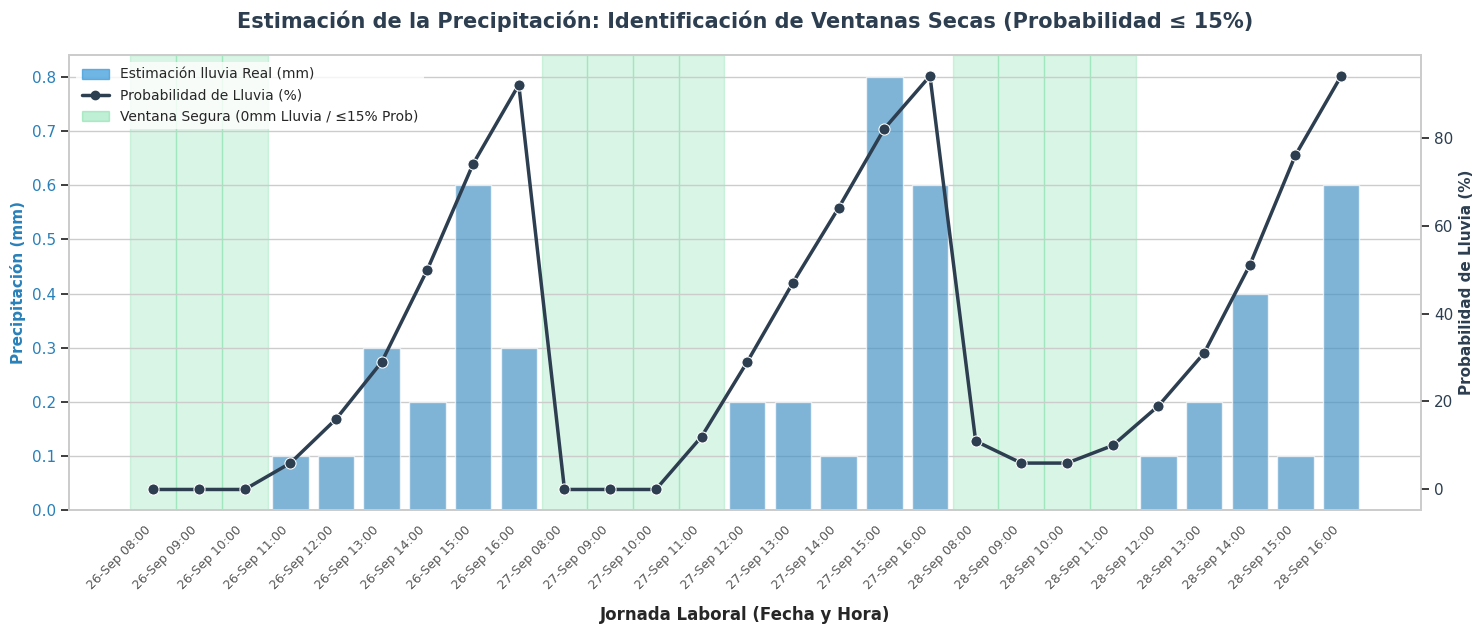

El análisis de las variables muestra un comportamiento cíclico y repetitivo a 
lo largo de las jornadas, caracterizado por una estabilidad con valores mínimos 
durante las horas de la mañana y un incremento sistemático de los picos máximos 
en el bloque vespertino. Con una alta correlación entre ambas curvas, 
donde el aumento en el porcentaje de probabilidad anticipa o acompaña de forma directa 
al registro de la estimacion de la precipitación.
Ademas, muestra que las ventanas de vuelo seguro donde la estimación de precipitación es 
menor o igual 15%, las cuales se concentra en el segmento de la mañana 


In [219]:
print(" • " * 20)
print(f"\033[1mUna grafica que indique las caracteristicas del tiempo en la zona de vuelo con el drone para tres días despúes. \033[0m")

# Configuración de estilo y lienzo
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(15, 6.5))

# Aseguramos posiciones numéricas fijas para que barras y líneas se alineen perfectamente
posiciones_x = range(len(df_laboral1))

# Definición de Ventana Seca con Umbral (Sin lluvia y probabilidad <= 15%)
condicion_seco = (df_laboral1["precipitation"] == 0) & (
    df_laboral1["precipitation_probability"] <= 15.0
)

# Renderizar franjas verdes de fondo
for idx, is_dry in enumerate(condicion_seco):
    if is_dry:
        ax1.axvspan(
            idx - 0.5,
            idx + 0.5,
            color="#2ecc71",
            alpha=0.18,  # Un poco más visible
            zorder=0,
        )

# Gráfico de Barras: Lluvia Real (Eje Izquierdo)
sns.barplot(
    data=df_laboral1,
    x="dia_hora",
    y="precipitation",
    color="#3498db",
    alpha=0.7,
    ax=ax1,
    zorder=2,
)
ax1.set_ylabel("Precipitación (mm)", color="#2980b9", fontweight="bold", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#2980b9")
ax1.set_xlabel("Jornada Laboral (Fecha y Hora)", fontweight="bold", labelpad=10)

# Gráfico de Línea: Probabilidad (Eje Derecho)
ax2 = ax1.twinx()
# Forzamos a la línea a usar 'posiciones_x' para que encaje simétricamente con las barras
sns.lineplot(
    x=posiciones_x,
    y=df_laboral1["precipitation_probability"],
    color="#2c3e50",
    marker="o",
    markersize=8,
    linewidth=2.5,
    ax=ax2,
    zorder=3,
)
ax2.set_ylabel(
    "Probabilidad de Lluvia (%)", color="#2c3e50", fontweight="bold", fontsize=11
)
ax2.tick_params(axis="y", labelcolor="#2c3e50")
ax2.grid(False)  # Evita duplicar líneas de cuadrícula

# Formatear y fijar eje X de forma estricta
ax1.set_xticks(posiciones_x)
ax1.set_xticklabels(
    df_laboral1["dia_hora"], rotation=45, ha="right", fontsize=9, color="#555555"
)

# Leyenda Unificada Avanzada
patch_lluvia = mpatches.Patch(color="#3498db", alpha=0.7, label="Estimación lluvia Real (mm)")
linea_prob = plt.Line2D(
    [],
    [],
    color="#2c3e50",
    marker="o",
    linewidth=2.5,
    label="Probabilidad de Lluvia (%)",
)
patch_seco = mpatches.Patch(
    color="#2ecc71", alpha=0.3, label="Ventana Segura (0mm Lluvia / ≤15% Prob)"
)

plt.legend(
    handles=[patch_lluvia, linea_prob, patch_seco],
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=10,
)

# Título Limpio (Sin emojis problemáticos para las fuentes)
plt.title(
    "Estimación de la Precipitación: Identificación de Ventanas Secas (Probabilidad ≤ 15%)",
    fontsize=15,
    fontweight="bold",
    pad=20,
    color="#2c3e50",
)

plt.tight_layout()
plt.show()

print("""El análisis de las variables muestra un comportamiento cíclico y repetitivo a
lo largo de las jornadas, caracterizado por una estabilidad con valores mínimos
durante las horas de la mañana y un incremento sistemático de los picos máximos
en el bloque vespertino. Con una alta correlación entre ambas curvas,
donde el aumento en el porcentaje de probabilidad anticipa o acompaña de forma directa
al registro de la estimacion de la precipitación.
Ademas, muestra que las ventanas de vuelo seguro donde la estimación de precipitación es
menor o igual 15%, las cuales se concentra en el segmento de la mañana """)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Segunda grafica que indique las caracteristicas del tiempo en la zona de vuelo con el drone para tres días despúes. 


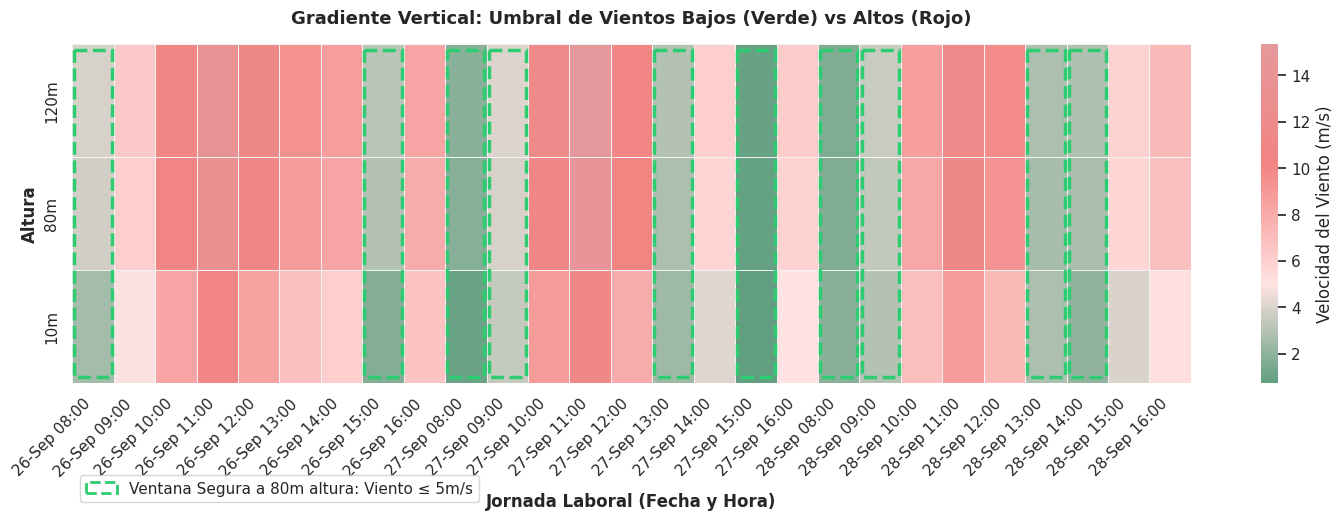

El análisis del gradiente vertical de vientos revela un patrón espacio-temporal,
donde las mayores velocidades (tonos rojos, superiores a 8-10 m/s) se 
concentran sistemáticamente durante las horas centrales y vespertinas de cada jornada. 
Por el contrario, se identifican ventanas de operación segura con vientos bajos 
(tonos verdes y grisáceos, inferiores a 4-6 m/s) principalmente en las primeras horas de
la mañana (08:00 a 09:00), observándose el fenómeno de cizalladura o gradiente vertical 
donde la velocidad del viento se incrementa de manera proporcional con la altura en casi 
todos los intervalos medidos.


In [220]:
print(" • " * 20)
print(f"\033[1mSegunda grafica que indique las caracteristicas del tiempo en la zona de vuelo con el drone para tres días despúes. \033[0m")

# Preparar los datos (Cambiado a df_laboral1 para mantener consistencia)
df_heatmap = df_laboral1.set_index("dia_hora")[
    ["wind_speed_120m", "wind_speed_80m", "wind_speed_10m"]
].T
df_heatmap.index = df_heatmap.index.str.replace("wind_speed_", "")

# CREAR PALETA PERSONALIZADA (Verde -> Amarillo/Neutro -> Rojo)
colores = ["#1b4332", "#40916c", "#ffe3e2", "#f28482", "#e5989b"]
mi_mapa_color = mcolors.LinearSegmentedColormap.from_list(
    "viento_custom", colores
)

# Graficar
fig, ax = plt.subplots(figsize=(15, 5.5))

sns.heatmap(
    df_heatmap,
    cmap=mi_mapa_color,
    center=5,
    cbar_kws={"label": "Velocidad del Viento (m/s)"},
    linewidths=0.5,
    linecolor="#f1f3f5",
    ax=ax,
)

# DESTACAR COLUMNAS CON VIENTO <= 5 m/s
# Condición: Evaluamos si el viento a nivel de operación 80m de alturas es <= 5.
# En este ejemplo, evaluamos si la velocidad a 10m (que es la última fila del Heatmap) es <= 5.
# Nota: Si prefieres que TODAS las alturas sean <=5, usa: (df_heatmap <= 5).all()
condicion_viento_seguro = df_heatmap.loc["80m"] <= 5.0

for idx, es_seguro in enumerate(condicion_viento_seguro):
    if es_seguro:
        # Añadimos un recuadro de línea discontinua gruesa sobre toda la columna
        rect = mpatches.Rectangle(
            (idx + 0.05, 0.05),  # Ajuste de coordenadas para no tapar los bordes blancos
            0.9,  # Ancho del recuadro
            df_heatmap.shape[0] - 0.1,  # Alto total (número de filas)
            fill=False,
            edgecolor="#2ecc71",  # Verde brillante para que contraste con los tonos oscuros
            linestyle="--",
            linewidth=2.5,
            zorder=5,  # Lo posiciona por encima del mapa de calor
        )
        ax.add_patch(rect)

# Personalización final y Leyenda Explicativa
plt.title(
    "Gradiente Vertical: Umbral de Vientos Bajos (Verde) vs Altos (Rojo)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Jornada Laboral (Fecha y Hora)", fontweight="bold", labelpad=10)
plt.ylabel("Altura", fontweight="bold")
plt.xticks(rotation=45, ha="right")

# Añadir una pequeña leyenda personalizada para el recuadro de destaque
patch_destaque = mpatches.Patch(
    edgecolor="#2ecc71",
    facecolor="none",
    linestyle="--",
    linewidth=2,
    label="Ventana Segura a 80m altura: Viento ≤ 5m/s",
)
plt.legend(handles=[patch_destaque], loc="upper left", bbox_to_anchor=(0, -0.25))

plt.tight_layout()
plt.show()
print("""El análisis del gradiente vertical de vientos revela un patrón espacio-temporal,
donde las mayores velocidades (tonos rojos, superiores a 8-10 m/s) se
concentran sistemáticamente durante las horas centrales y vespertinas de cada jornada.
Por el contrario, se identifican ventanas de operación segura con vientos bajos
(tonos verdes y grisáceos, inferiores a 4-6 m/s) principalmente en las primeras horas de
la mañana (08:00 a 09:00), observándose el fenómeno de cizalladura o gradiente vertical
donde la velocidad del viento se incrementa de manera proporcional con la altura en casi
todos los intervalos medidos.""")

In [221]:
print(" • " * 20)
print(f"\033[1m¿Cuál es la mejor hora del día para realizar un vuelo seguro con el drone.? \033[0m")
# Definir la máscara lógica combinando todas tus condiciones
condicion_ideal = (
    (df_laboral1["precipitation"] == 0) &
    (df_laboral1["precipitation_probability"] <= 15.0) &
    (df_laboral1["wind_speed_80m"] <= 5.0) &
    (df_laboral1["wind_speed_10m"] <= 5.0)
)

# Filtrar el DataFrame original para extraer solo las filas que cumplen todo
df_ventanas_perfectas = df_laboral1[condicion_ideal].copy()

# Mostrar el resultado resumido en consola
print(f"✅ Se encontraron {len(df_ventanas_perfectas)} horas con condiciones perfectas.\n")
print(df_ventanas_perfectas[["dia_hora", "precipitation", "precipitation_probability", "wind_speed_80m", "wind_speed_10m"]])
#print(df_ventanas_perfectas.head)
#df_ventanas_perfectas.describe().T


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
¿Cuál es la mejor hora del día para realizar un vuelo seguro con el drone.? 
✅ Se encontraron 5 horas con condiciones perfectas.

         dia_hora  precipitation  precipitation_probability  wind_speed_80m  \
104  26-Sep 08:00            0.0                        0.0        3.787282   
128  27-Sep 08:00            0.0                        0.0        1.754425   
129  27-Sep 09:00            0.0                        0.0        3.883584   
152  28-Sep 08:00            0.0                       11.0        1.569205   
153  28-Sep 09:00            0.0                        6.0        3.351823   

     wind_speed_10m  
104        2.520000  
128        1.049571  
129        3.438895  
152        1.772794  
153        2.995797  


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Tablero que muestra  la mejor rango de hora del día para realizar un vuelo seguro con el drone. 


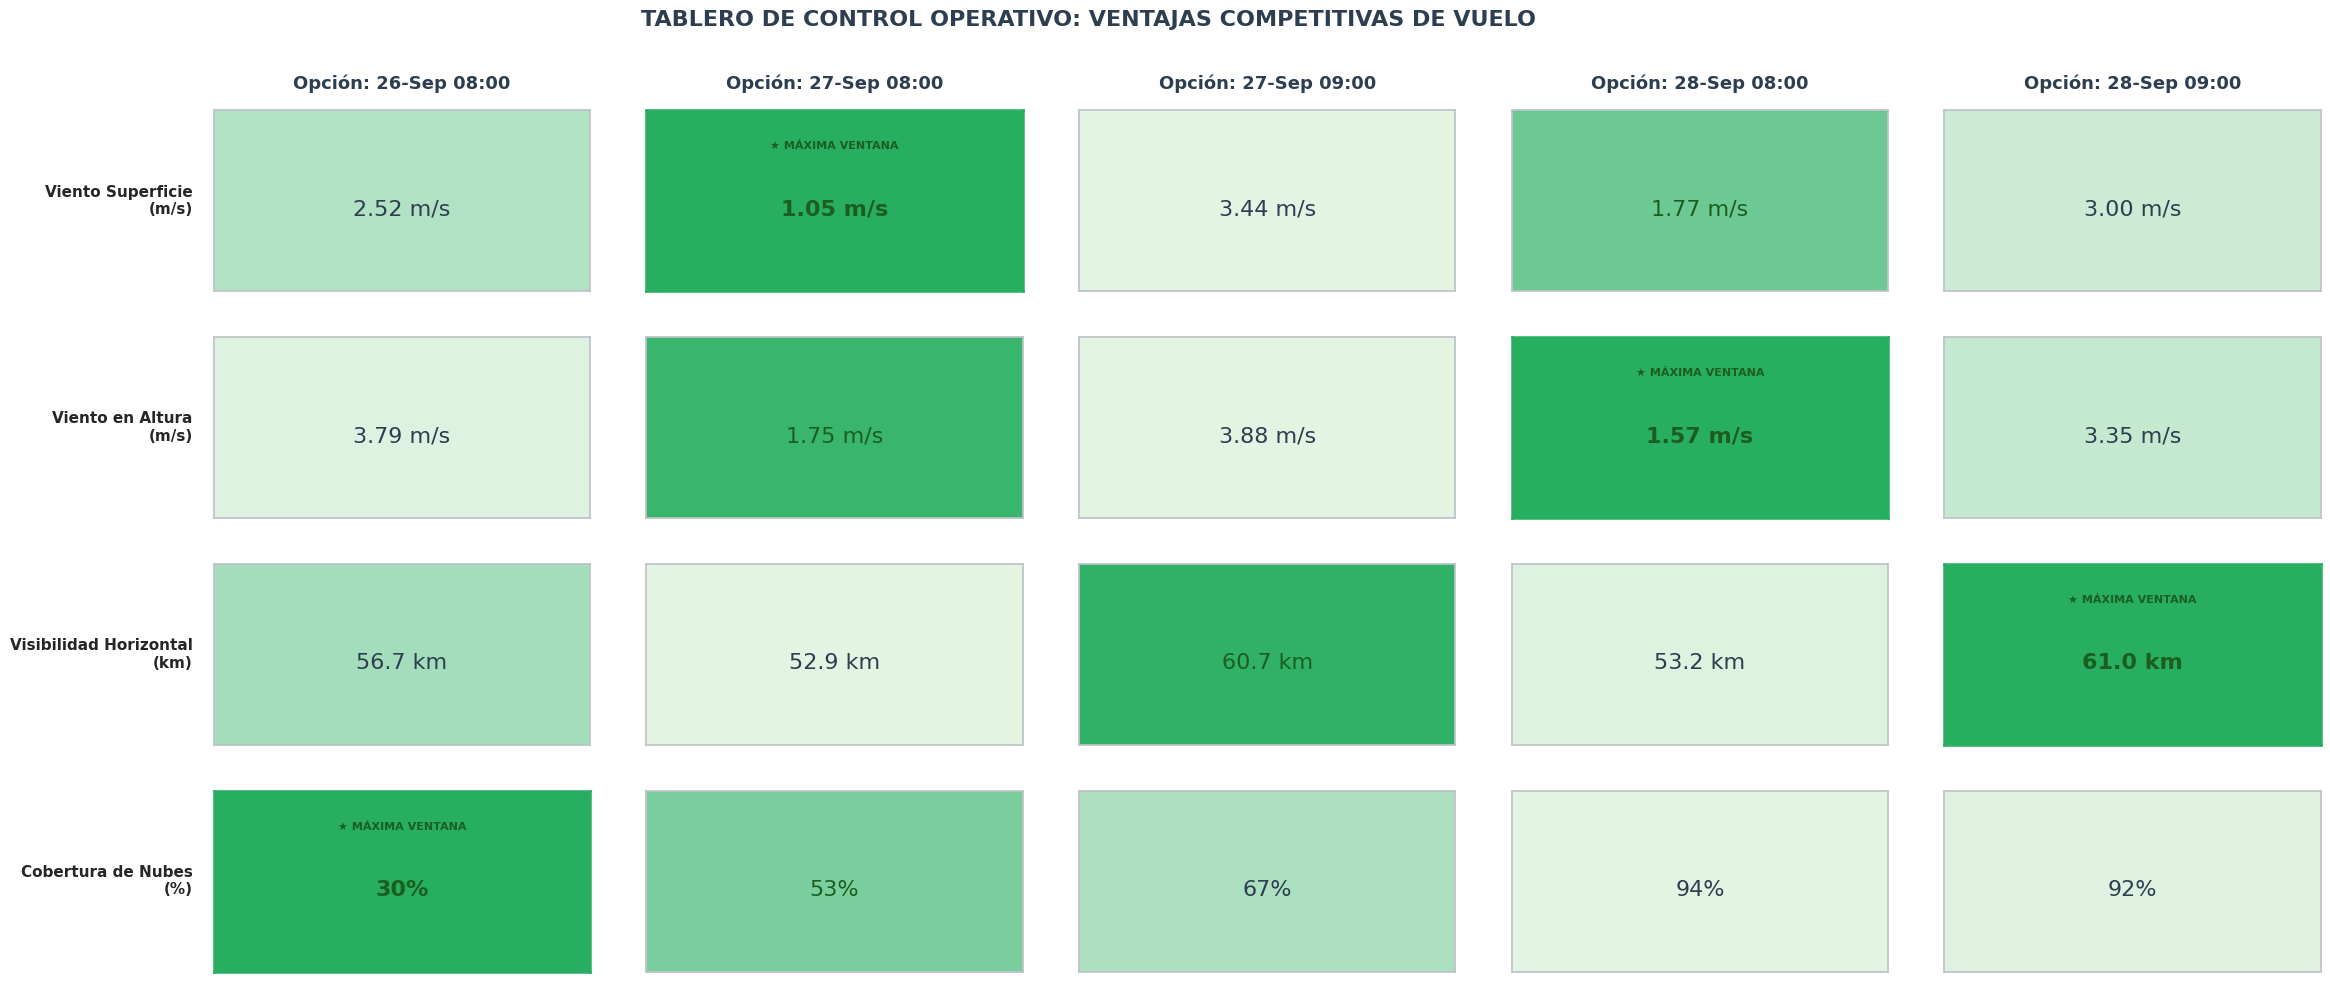

El rango horario óptimo para un vuelo seguro se concentra en la sección matutina. 
Dadas las opciones del tablero, se pueden aplicar criterios de selección específicos 
para discriminar entre las posibilidades según el objetivo de la misión:

• Vuelo Recreativo: Se puede utilizar la variable de 'Viento en Superficie' como factor 
  de decisión para garantizar un despegue y aterrizaje estables.
• Vuelo a Gran Altura: Si se busca operar en una ruta definida a más metros de elevación, 
  la variable de 'Vientos en Altura' permite identificar la menor resistencia del aire.
• Máximo Alcance Visual: Si la prioridad es optimizar el campo de visión del piloto, 
  la variable de 'Visibilidad Horizontal' indicará la opción con mayor alcance en kilómetros.
• Inspección Fotográfica: Si se requiere evitar sombras proyectadas en el terreno, 
  se debe seleccionar el menor porcentaje en la variable de 'Cobertura de Nubes'.


In [222]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns

print(" • " * 20)
print(f"\033[1mTablero que muestra  la mejor rango de hora del día para realizar un vuelo seguro con el drone. \033[0m")

# ==========================================
# CONFIGURACIÓN DINÁMICA DE COLUMNAS
# ==========================================
num_columnas = len(df_ventanas_perfectas)

# Configuración del diseño del Tablero
sns.set_theme(style="white")
fig, axes = plt.subplots(4, num_columnas, figsize=(5 * num_columnas, 10), sharex=True)

# Forzar a que axes siempre sea una matriz bidimensional
if num_columnas == 1:
    axes = axes.reshape(-1, 1)

# Lista de las opciones para los títulos de las columnas
opciones = df_ventanas_perfectas["dia_hora"].tolist()

# Variables clave a contrastar
metricas = [
    {"col": "wind_speed_10m", "label": "Viento Superficie\n(m/s)", "invert": True, "fmt": "{:.2f} m/s"},
    {"col": "wind_speed_80m", "label": "Viento en Altura\n(m/s)", "invert": True, "fmt": "{:.2f} m/s"},
    {"col": "visibility", "label": "Visibilidad Horizontal\n(km)", "invert": False, "fmt": "{:.1f} km"},
    {"col": "cloud_cover", "label": "Cobertura de Nubes\n(%)", "invert": True, "fmt": "{:.0f}%"}
]

# Modificación temporal para transformar visibilidad a KM antes de graficar
df_tablero = df_ventanas_perfectas.copy()
df_tablero["visibility"] = df_tablero["visibility"] / 1000.0

# Definir un mapa de color personalizado que va desde un verde muy claro (aceptable) hasta un verde intenso (perfecto)
cmap_verde = mcolors.LinearSegmentedColormap.from_list("gradiente_vuelo", ["#f1f9ec", "#a9dfbf", "#27ae60"])

# Construcción dinámica de las tarjetas del tablero
for row_idx, metrica in enumerate(metricas):
    col_name = metrica["col"]

    # Obtener el rango de valores de la fila actual para normalizar
    val_min = df_tablero[col_name].min()
    val_max = df_tablero[col_name].max()
    val_range = val_max - val_min if val_max != val_min else 1.0

    # Identificar cuál opción tiene la ventaja absoluta para la etiqueta de texto
    if metrica["invert"]:
        idx_ganador_absoluto = df_tablero[col_name].idxmin()
    else:
        idx_ganador_absoluto = df_tablero[col_name].idxmax()

    for col_idx, idx_fila in enumerate(df_tablero.index):
        ax = axes[row_idx, col_idx]
        valor = df_tablero.loc[idx_fila, col_name]

        # Calcular el puntaje de idoneidad (0.0 = el menos óptimo de la fila, 1.0 = el más óptimo de la fila)
        if metrica["invert"]:
            score = (val_max - valor) / val_range  # Menor valor es mejor score
        else:
            score = (valor - val_min) / val_range  # Mayor valor es mejor score

        # Asignar color de fondo basado en el gradiente de idoneidad
        bg_color = mcolors.to_hex(cmap_verde(0.1 + 0.9 * score))  # Evita que el peor sea 100% blanco

        # Estilos de texto adaptativos
        es_ganador_absoluto = (idx_fila == idx_ganador_absoluto)
        text_color = "#1b5e20" if score > 0.6 else "#2c3e50"
        weight = "bold" if es_ganador_absoluto else "normal"

        # Dibujar la tarjeta visual (Fondo sólido dinámico)
        ax.set_facecolor(bg_color)

        # Insertar el indicador numérico central
        ax.text(0.5, 0.45, metrica["fmt"].format(valor),
                fontsize=16, fontweight=weight, color=text_color,
                ha="center", va="center", transform=ax.transAxes)

        # Agregar etiqueta solo a la opción que tiene la "Ventaja Máxima Absoluta" en la fila
        if es_ganador_absoluto:
            ax.text(0.5, 0.8, "★ MÁXIMA VENTANA",
                    fontsize=8, fontweight="bold", color="#1b5e20",
                    ha="center", va="center", transform=ax.transAxes)

        # Configuración estética de los bordes de cada tarjeta
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color("#27ae60" if es_ganador_absoluto else "#bdc3c7")
            if es_ganador_absoluto:
                spine.set_linewidth(1.8)

    # Colocar el nombre del indicador a la izquierda de la fila
    axes[row_idx, 0].set_ylabel(metrica["label"], fontsize=11, fontweight="bold", labelpad=15, rotation=0, ha="right", va="center")

# Encabezados del Tablero (Fechas de las opciones)
for col_idx, opcion in enumerate(opciones):
    axes[0, col_idx].set_title(f"Opción: {opcion}", fontsize=13, fontweight="bold", pad=15, color="#2c3e50")

plt.suptitle("TABLERO DE CONTROL OPERATIVO: VENTAJAS COMPETITIVAS DE VUELO",
             fontsize=16, fontweight="bold", y=0.98, color="#2c3e50")
plt.tight_layout()

# Ajuste adaptativo del margen izquierdo según el ancho del tablero
plt.subplots_adjust(left=0.25 if num_columnas <= 3 else 0.15, top=0.88, hspace=0.25, wspace=0.15)
plt.show()

print("""El rango horario óptimo para un vuelo seguro se concentra en la sección matutina.
Dadas las opciones del tablero, se pueden aplicar criterios de selección específicos
para discriminar entre las posibilidades según el objetivo de la misión:

• Vuelo Recreativo: Se puede utilizar la variable de 'Viento en Superficie' como factor
  de decisión para garantizar un despegue y aterrizaje estables.
• Vuelo a Gran Altura: Si se busca operar en una ruta definida a más metros de elevación,
  la variable de 'Vientos en Altura' permite identificar la menor resistencia del aire.
• Máximo Alcance Visual: Si la prioridad es optimizar el campo de visión del piloto,
  la variable de 'Visibilidad Horizontal' indicará la opción con mayor alcance en kilómetros.
• Inspección Fotográfica: Si se requiere evitar sombras proyectadas en el terreno,
  se debe seleccionar el menor porcentaje en la variable de 'Cobertura de Nubes'.""")
